Plan:

Explore dataset for Ride Knox 2026
Clean dataset for Ride Knox 2026
    1. Remove duplicate entries
    2. Determine whether there are empty or NA entries
    3. Correct syntax errors and standardize labeling
    4. Add in more specific columns for date, time, day of week
    5. Finalize a pipeline


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [3]:
def clean_trips(path, remove_test_station=False):
    """Load and clean a Ride Knox trip file. Prints a row-count audit trail."""
    trips = pd.read_csv(path)
    n0 = len(trips)
    print(f"{path}: {n0:,} raw rows")

    trips = trips.drop_duplicates()
    print(f"  after dropping exact duplicates: {len(trips):,} "
          f"(-{n0 - len(trips)})")

    trips = trips.copy()
    trips["rider_type"] = (trips["rider_type"].str.strip()
                                              .str.lower()
                                              .str.replace(" ", "_"))
    print(f"  rider_type categories: {sorted(trips['rider_type'].unique())}")

    if remove_test_station:
        before = len(trips)
        trips = trips[trips["start_station_id"] != "S99"]
        print(f"  after removing S99 test-station trips: {len(trips):,} "
              f"(-{before - len(trips)})")

    trips["start_time"] = pd.to_datetime(trips["start_time"])
    trips["end_time"] = pd.to_datetime(trips["end_time"])
    trips["duration_min"] = ((trips["end_time"] - trips["start_time"])
                             .dt.total_seconds() / 60)
    trips["missing_end_time"] = trips["end_time"].isna()
    print(f"  trips with missing end_time (kept, flagged): "
          f"{trips['missing_end_time'].sum():,}")

    # Keep rows whose duration is unknown OR within 1 min - 24 h.
    # The explicit isna() term matters: a bare (d >= 1) & (d <= 1440) would
    # silently drop every missing-end_time row from the counts too.
    d = trips["duration_min"]
    keep = d.isna() | ((d >= 2) & (d <= 1440)) 
    
    before = len(trips)
    trips = trips[keep].copy()
    print(f"  after removing durations outside 2 min-24 h: {len(trips):,} "
          f"(-{before - len(trips)})")

    trips["month"] = trips["start_time"].dt.month
    trips["is_weekend"] = trips["start_time"].dt.dayofweek >= 5
    return trips

trips_2026 = clean_trips("trips_2026_h1.csv")

trips_2026_h1.csv: 137,341 raw rows
  after dropping exact duplicates: 136,991 (-350)
  rider_type categories: ['casual', 'day_pass', 'member']
  trips with missing end_time (kept, flagged): 800
  after removing durations outside 2 min-24 h: 136,345 (-646)


In [7]:
stations_2026 = pd.read_excel("stations_2026.xlsx")

### Explore 2026 data, make note/observations of changes needed.

In [8]:
# Explore the data:
print(trips_2026.shape)
print(trips_2026.columns)

print(stations_2026.shape)
print(stations_2026.columns)

(136345, 12)
Index(['trip_id', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'end_station_id', 'rider_type', 'bike_type',
       'duration_min', 'missing_end_time', 'month', 'is_weekend'],
      dtype='str')
(25, 7)
Index(['station_id', 'station_name', 'neighborhood', 'latitude', 'longitude',
       'docks', 'year_installed'],
      dtype='str')


In [9]:
merged_2026 = pd.merge(
    trips_2026, stations_2026,
    left_on="start_station_id", right_on="station_id",
    how="left",
)
assert len(merged_2026) == len(trips_2026)  


print(f"Shape of trips: {trips_2026.shape}")
print(f"Shape of merged: {merged_2026.shape}")

Shape of trips: (136345, 12)
Shape of merged: (136345, 19)


In [10]:
# TODO: random sample and describe
display(merged_2026.sample(5))
display(merged_2026.describe())

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type,duration_min,missing_end_time,month,is_weekend,station_id,station_name,neighborhood,latitude,longitude,docks,year_installed
33615,T0350484,2026-03-17 16:35:54,2026-03-17 16:54:42,S20,Zoo Knoxville,S11,member,classic,18.800000,False,3,False,S20,Zoo Knoxville,East Knoxville,35.9863,-83.8880,10,2024
97046,T0397083,2026-05-27 16:23:59,2026-05-27 16:41:31,S01,Market Square,S02,casual,classic,17.533333,False,5,False,S01,Market Square,Downtown,35.9649,-83.9197,20,2022
17979,T0409526,2026-02-18 11:09:13,2026-02-18 11:24:19,S09,Neyland Stadium,NaN,member,electric,15.100000,False,2,False,S09,Neyland Stadium,UT Campus,35.9550,-83.9250,16,2023
106968,T0355593,2026-06-06 08:16:23,2026-06-06 08:27:17,S18,Fourth & Gill,S13,member,classic,10.900000,False,6,True,S18,Fourth & Gill,North Knoxville,35.9770,-83.9170,10,2024
45401,T0348374,2026-04-03 19:04:06,2026-04-03 19:15:02,S25,Cumberland Ave & 22nd St,S10,member,classic,10.933333,False,4,False,S25,Cumberland Ave & 22nd St,Fort Sanders,35.9568,-83.9352,16,2026


,start_time,end_time,duration_min,month,latitude,longitude,docks,year_installed
count,136345,135545,135545.000000,136345.000000,136345.000000,136345.000000,136345.000000,136345.000000
mean,2026-04-22 02:59:24.095662,2026-04-22 15:42:18.019359,17.520101,4.189226,35.961015,-83.924360,17.726913,2022.670410
min,2026-01-01 00:27:32,2026-01-01 00:35:34,2.000000,1.000000,35.939000,-83.979000,10.000000,2022.000000
25%,2026-03-18 13:13:50,2026-03-19 13:09:57,9.300000,3.000000,35.955300,-83.929500,12.000000,2022.000000
50%,2026-04-29 14:54:21,2026-04-30 00:58:07,14.133333,4.000000,35.957500,-83.925600,16.000000,2022.000000
75%,2026-06-01 16:16:07,2026-06-01 18:51:21,21.783333,6.000000,35.964900,-83.918600,20.000000,2023.000000
max,2026-06-30 23:54:06,2026-07-01 00:20:24,197.033333,6.000000,35.986300,-83.868000,32.000000,2026.000000
std,NaN,NaN,12.646352,1.552259,0.008922,0.013773,7.312881,1.056877


In [13]:
# TODO: timestamp
# e.g. pd.to_datetime(..., errors="coerce") and see what fails to parse
merged_2026["start_time"] = pd.to_datetime(merged_2026["start_time"])
merged_2026["end_time"] = pd.to_datetime(merged_2026["end_time"], errors="coerce")
merged_2026["duration_min"] = (merged_2026["end_time"] - merged_2026["start_time"]).dt.total_seconds() / 60

merged_2026 = merged_2026[(merged_2026["duration_min"] >= 1) & (merged_2026["duration_min"] <= 24 * 60)]
merged_2026['duration_sec']= (merged_2026['end_time'] - merged_2026['start_time']).dt.total_seconds()

In [14]:
merged_2026['duration_sec'].describe

<bound method NDFrame.describe of 0          482.0
1         1230.0
2          578.0
3         1578.0
4         1021.0
           ...  
136340    1405.0
136341    1178.0
136342     568.0
136343     903.0
136344     435.0
Name: duration_sec, Length: 135545, dtype: float64>

In [15]:
# Compare member trips across the available calendar-year data.
# Note: 2026 contains January–June only, so this is not a full-year comparison.

member_counts_2026_available = (
    merged_2026["rider_type"] == "member"
).sum()


print(f"Member trips, January–June 2026: {member_counts_2026_available:,}")

Member trips, January–June 2026: 79,550


In [17]:
#TODO compare day pass trips and casual trips for non-members
day_pass_trips_2026 = merged_2026[merged_2026["rider_type"] == "day_pass"]
casual_trips_2026 = merged_2026[merged_2026["rider_type"] == "casual"]

print(f"Day pass trips, Jan–Jun 2026: {len(day_pass_trips_2026)}")
print(f"Casual trips, Jan–Jun 2026: {len(casual_trips_2026)}")



Day pass trips, Jan–Jun 2026: 10886
Casual trips, Jan–Jun 2026: 45109


In [19]:
# what percentage of non-member riders in 2026 opt for a day pass over being a casual rider?
non_members_day_pass_percentage = len(day_pass_trips_2026) / (len(casual_trips_2026) + len(day_pass_trips_2026)) * 100
print(f"Percentage of non-member riders in 2026 opting for a day pass: {non_members_day_pass_percentage:.2f}%")
non_members_casual_percentage = len(casual_trips_2026) / (len(casual_trips_2026) + len(day_pass_trips_2026)) * 100
print(f"Percentage of non-member riders in 2026 opting for a casual ride: {non_members_casual_percentage:.2f}%")    

Percentage of non-member riders in 2026 opting for a day pass: 19.44%
Percentage of non-member riders in 2026 opting for a casual ride: 80.56%


## Analysis: Did non-membership recover?

Yes, but are not seeing a meaningful increase of casual ridership from 2025 to 2026. In the following analysis, non-members include day pass riders and casual riders for 2026.

Non-member trips, Jan–Jun 2025: 57193
Non-member trips, Jan–Jun 2026: 56124
Difference for non-members: -1069
User difference for non-members: -1.87%

Note, I am only comparing across Jan-Jun because that is all that is available for 2026, and we also want to see the usage before the price increase went into affect in July 2025. 

Usage for non-members is down 1.87% from 2025 pre-price increase in 2026. 

However, it does seem like 19.45% of non-member users in 2026 are opting for day passes over just using a one-trip casual ride.

In the figure "Non-member Ridership: 2025 vs 2026 (Jan-Jun)" we can see that ridership for non-members is on an increasing trend in comparison to 2025. While, currently combined non-membership rides for 2026 is slightly below 2026, it is greater in months following March of 2026 than it was in Months following March in 2025. The day pass was implemented in March and may be responsible for this positive trend.

To elaborate, if we just look at the May of 2026 (most recent logged month) we can see that casual rider ship is up 7.51% from May of 2025, which is an increase of 992 trips. Approximately a quarter of these trips in May were day pass users.



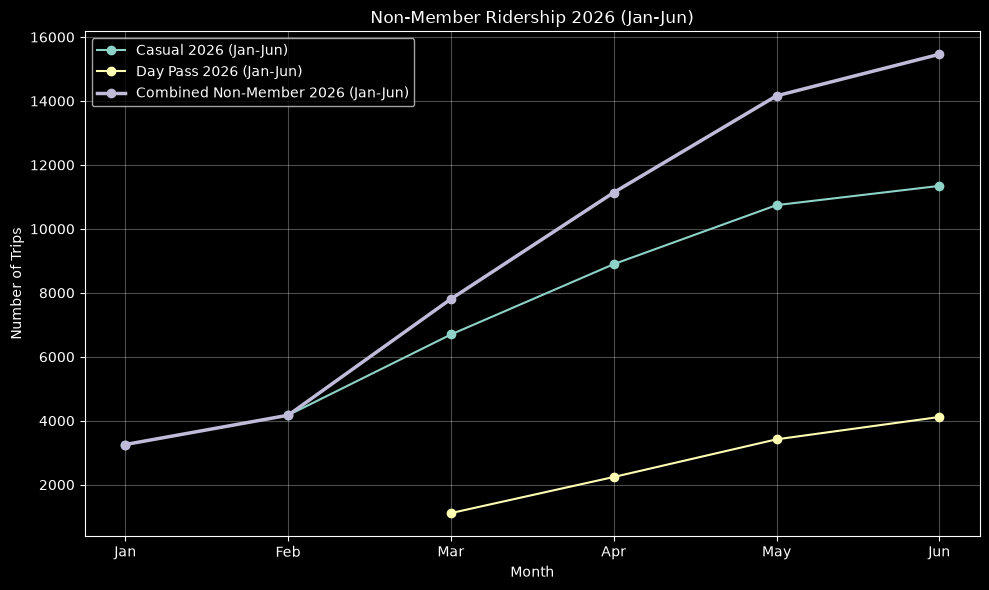

<Figure size 640x480 with 0 Axes>

In [24]:
# Build monthly counts for non-member ridership comparison (Jan-Jun 2025 vs Jan-Jun 2026)
months = range(1, 7)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

non_member_trips_2026 = pd.concat(
    [casual_trips_2026, day_pass_trips_2026],
    ignore_index=True
)

casual_2026_monthly = casual_trips_2026.groupby("month").size().reindex(months)
day_pass_2026_monthly = day_pass_trips_2026.groupby("month").size().reindex(months)
non_member_2026_monthly = non_member_trips_2026.groupby("month").size().reindex(months)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(month_labels, casual_2026_monthly, marker='o', label="Casual 2026 (Jan-Jun)")
ax.plot(month_labels, day_pass_2026_monthly, marker='o', label="Day Pass 2026 (Jan-Jun)")
ax.plot(month_labels, non_member_2026_monthly, marker='o', label="Combined Non-Member 2026 (Jan-Jun)", linewidth=2.5)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Trips")
ax.set_title("Non-Member Ridership 2026 (Jan-Jun)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# save to folder -- charts
plt.savefig("charts/non_member_ridership_2026.png")

## Who are the day pass riders?

Are they riding on weekends or during the week? 
How long are the trips of day pass riders in 2026? 
How long does the trips of day pass riders compare to casual riders in 2025?

In [27]:
# remember to use "merged_2025_jan_jun" and "merged_2026"

merged_2026_day_pass = merged_2026[merged_2026["rider_type"] == "day_pass"]


# what days of the week have the most day pass riders in 2026 group by "day_name"
merged_2026_day_pass = merged_2026[merged_2026["rider_type"] == "day_pass"].copy()
merged_2026_day_pass["day_name"] = merged_2026_day_pass["start_time"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_pass_days_2026 = (
    merged_2026_day_pass.groupby("day_name")
    .size()
    .reset_index(name="trips")
)

day_pass_days_2026["day_name"] = pd.Categorical(
    day_pass_days_2026["day_name"],
    categories=day_order,
    ordered=True
)
day_pass_days_2026 = day_pass_days_2026.sort_values("day_name").reset_index(drop=True)
display(day_pass_days_2026)

,day_name,trips
0,Monday,847
1,Tuesday,899
2,Wednesday,825
3,Thursday,805
4,Friday,839
5,Saturday,3298
6,Sunday,3373


## Analysis: Who are the day pass riders?

The day pass riders are mostly riding on the weekends. As we can see in the "Average Trips per Day of Week by Rider Type (2025 vs 2026)?" plot day pass riders are mostly riding on Sat and Sun. The trips for casual and member riders stays consistent during from 2025 to 2026 for all weekdays.

## Memo:
The data for Ride Knox 2026 shows that casual riders and non-member riders are returning. In the figure "Non-member Ridership: 2025 vs 2026 (Jan-Jun)" we can see that ridership for non-members is on an increasing trend in comparison to 2025. While, currently combined non-membership rides for 2026 is slightly below 2026, it is greater in months following March of 2026 than it was in Months following March in 2025. The day pass was implemented in March and may be responsible for this positive trend.

To elaborate, if we just look at the May of 2026 (most recent logged month) we can see that casual rider ship is up 7.51% from May of 2025, which is an increase of 992 trips. Approximately a quarter of these trips in May were day pass users.

Additionally, we can see the behavior of day pass users by looking at trips taken on specific days of the week. Day pass use increases on Sat and Sun. The usage for other rider types is consistent to pre-price increase in 2025. The trend can be seen in "Average Trips per Day of Week by Rider Type (2025 vs 2026)".

For the dock expansion of S06 and S08, we can see that pressure decreased in this area by ~30%, the figure "Trips per Dock at S06 and S08: 2025 vs. 2026 (Jan–Jun)" shows the difference in pressure after the expansion. To add, the new dock S25 is performing relatively well, ranking in the 8th most pressured dock.

Overall, day passes have seemed to bring back some users to Ride Knox and may be responsible for additional weekend usage. For the future, Ride Knox may consider specials or different pricing for University Games or special events. 

For more information see project_outline_exp.ipynb and "Analysis" comments for elaboration on specific findings.



## AI usage:

I used AI to mostly help with some plotting. I especially got confused on plotting average trips per day by rider type. I struggled to parse the data properly and was getting a lot of errors so I asked copilot for assistance. 
Other wise I used my previous notebooks and assignments to help and guide my work.